In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import sys
import random
import math
import io
import json, time
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve

import torch.optim as optim
import torchaudio
    import zipfile, subprocess

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import soundfile as sf

In [ ]:

DATASET = "asvspoof"

SAMPLE_RATE = 16000
GCS_URI = "gs://ai600_project/dataset/LA.zip"
DATASET_SAVE    = "/content/drive/MyDrive/MSAI/AI-600/project/dataset/"
SUBSET_PER_CLASS = None
MAX_LEN = 32000 
BATCH_SIZE= 32 
LEARNING_RATE= 1e-4
EPOCHS=30
MODEL_SAVE= "/content/drive/MyDrive/MSAI/AI-600/project/results/best_model_asvspoof.pt"
N_CLASSES= 2
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
# !pip install crcmod -q

# !gsutil -m cp gs://ai600_project/dataset/LA.zip \
#     "/content/drive/MyDrive/DL/project/dataset/LA.zip"

In [ ]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    LOCAL_CACHE_DIR = "/content/asvspoof2019_cache/"
    print("Environment: Google Colab")
    from google.colab import auth, drive
    auth.authenticate_user() 
    print("GCS authenticated.")
    drive.mount("/content/drive")
    os.makedirs("/content/drive/MyDrive/MSAI/AI-600/project/results/", exist_ok=True)
    print("Google Drive mounted.")
else:
    LOCAL_CACHE_DIR = os.path.expanduser("~/asvspoof2019_cache")
    print("Environment: local")

os.makedirs(LOCAL_CACHE_DIR, exist_ok=True)
print(f"Cache dir : {LOCAL_CACHE_DIR}")
print(f"GCS URI   : {GCS_URI}")

Environment: Google Colab
GCS authenticated.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Cache dir : /content/asvspoof2019_cache/
GCS URI   : gs://ai600_project/dataset/LA.zip


In [30]:
# !unzip "/content/drive/MyDrive/DL/project/dataset/LA.zip" -d /content/asvspoof2019_cache/

Archive:  /content/drive/MyDrive/DL/project/dataset/LA.zip
replace /content/asvspoof2019_cache/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [94]:
!find /content/asvspoof2019_cache -name "*.flac" | wc -l

122299


In [ ]:

def _find_data_root(search_dir):
    for root, dirs, _ in os.walk(search_dir):
        if "ASVspoof2019_LA_cm_protocols" in dirs:
            return root
    return None

def setup_asv_spoof(gcs_uri, cache_dir):

    os.makedirs(cache_dir, exist_ok=True)
    zip_path = os.path.join(cache_dir, "LA.zip")

    if not os.path.exists(zip_path):
        print(f"Downloding from path {gcs_uri} → {zip_path}")
        subprocess.run(
            ["gcloud", "storage", "cp", gcs_uri, zip_path],
            check=True
        )
        print("Download complete.")
    else:
        size_mb = os.path.getsize(zip_path) / 1e6
        print(f"Zip already cached: {zip_path}  ({size_mb:.0f} MB)")

    # ── Extract ──────
    data_root = _find_data_root(cache_dir)
    if data_root is None:
        print(f"Extracting {zip_path} ...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(cache_dir)
        data_root = _find_data_root(cache_dir)

    if data_root is None:
        print("- could not auto-detect data root.:")
        for name in sorted(os.listdir(cache_dir)):
            print(f"  {cache_dir}/{name}")
        raise RuntimeError(
            "Set data root manually to the folder containing "
            "ASVspoof2019_LA_cm_protocols/."
        )

    print(f"Data root : {data_root}")
    return data_root


In [ ]:
class SincConv1d(nn.Module):
    
    def __init__(self, out_channels, 
                 k_size, sample_rate=16000, 
                 scale="mel"):
        
        super().__init__()
        
        self.out_channels = out_channels
        self.k_size = k_size if k_size % 2 != 0 else k_size + 1
        self.sample_rate = sample_rate

        hz_points = self._get_hz_points(out_channels, sample_rate, scale)
        
        self.register_buffer('low_hz_',  hz_points[:-2].unsqueeze(1))
        self.register_buffer('band_hz_', (hz_points[1:-1] - hz_points[:-2]).unsqueeze(1))
        
        n = (self.k_size - 1) / 2
        
        self.register_buffer('n_',      torch.arange(-n, n + 1).float().unsqueeze(0))
        self.register_buffer('window_', torch.hamming_window(self.k_size))

    @staticmethod
    def _get_hz_points(out_channels, sample_rate, scale):
        
        nyquist  = sample_rate / 2
        n = out_channels + 2
        
        if scale == "mel":
            low_mel = 80.0
            high_mel = 2595 * math.log10(1 + nyquist / 700)
            mel_pts = torch.linspace(low_mel, high_mel, n)
            return 700 * (10 ** (mel_pts / 2595) - 1)
        
        elif scale == "linear":
            return torch.linspace(0, nyquist, n)
        
        elif scale == "inverse_mel":
            low_mel = 80.0
            high_mel = 2595 * math.log10(1 + nyquist / 700)
            mel_pts = torch.linspace(low_mel, high_mel, n)
            hz_mel   = 700 * (10 ** (mel_pts / 2595) - 1)
            return nyquist - hz_mel.flip(0)
        
        else:
            raise ValueError(f"scale must be 'mel', 'linear', or 'inverse_mel', got {scale!r}")

    def forward(self, x):
        
        low  = torch.clamp(self.low_hz_,  
                           min=50, max=self.sample_rate / 2 - 50)
        
        high = torch.clamp(self.low_hz_ + torch.abs(self.band_hz_),
                           min=50, max=self.sample_rate / 2 - 50)
        
        f_times_t_low = 2 * low  * self.n_ / self.sample_rate
        f_times_t_high = 2 * high * self.n_ / self.sample_rate
        
        bp_left = (torch.sin(math.pi * f_times_t_low)  / (math.pi * self.n_ + 1e-9)) * self.window_
        bp_right = (torch.sin(math.pi * f_times_t_high) / (math.pi * self.n_ + 1e-9)) * self.window_
        
        band_pass = bp_right - bp_left
        
        band_pass=band_pass / (band_pass.abs().max(dim=1, keepdim=True)[0] + 1e-9)
        
        return F.conv1d(x, band_pass.unsqueeze(1), padding=self.k_size // 2)

class MultiScaleSinc(nn.Module):
    
    def __init__(self, out_channels=80, k_size=251, sample_rate=16000):
        super().__init__()
        self.mel= SincConv1d(out_channels, k_size, sample_rate, scale="mel")
        self.linear = SincConv1d(out_channels, k_size, sample_rate, scale="linear")
        self.inverse_mel = SincConv1d(out_channels, k_size, sample_rate, scale="inverse_mel")
        self.bn = nn.InstanceNorm1d(out_channels * 3, affine=True)
        self.relu  = nn.LeakyReLU(0.1)

    def forward(self, x):                      # x: (B, 1, T)
        out = torch.cat([
            self.mel(x),                       # (B, 80, T)
            self.linear(x),                    # (B, 80, T)
            self.inverse_mel(x),               # (B, 80, T)
        ], dim=1)   
        # (B, 240, T)
        return self.relu(self.bn(out))

In [ ]:
class MultiScaleTemporal(nn.Module):
  def __init__(self, in_channels, out_channels, k_sizes=[5, 9, 15]):
    
    super().__init__()
    
    self.convs = nn.ModuleList([
      nn.Conv1d(in_channels, out_channels, 
                k_size=k, padding=k // 2)
      
      for k in k_sizes
    ])

    self.bn = nn.InstanceNorm1d(out_channels * 3, affine=True) 
    self.relu = nn.LeakyReLU(0.1)

  def forward(self, x): 
    out = []
    for conv in self.convs:
      out.append(conv(x))
      
    out= torch.cat(out, dim=1)
    out= self.bn(out)
    out = self.relu(out) 
    
    return out

In [ ]:

class FMS(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.fc  = nn.Linear(channels, channels)
        self.sig = nn.Sigmoid()

    def forward(self, x):
        s = x.mean(dim=-1)  
        s = self.sig(self.fc(s)) 
        return x * s.unsqueeze(-1)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, k_size=3, stride=1, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels,
                               k_size, stride=stride, 
                               padding=k_size // 2, bias=False)
        
        self.bn1= nn.InstanceNorm1d(out_channels, affine=True)

        self.conv2 = nn.Conv1d(out_channels, out_channels, k_size, 
                               padding=k_size // 2, bias=False)
        
        self.bn2 = nn.InstanceNorm1d(out_channels, affine=True)

        self.relu = nn.LeakyReLU(0.1)
        self.drop = nn.Dropout(dropout)

        self.fms= FMS(out_channels)

        self.skip = nn.Sequential()
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, k_size=1, stride=stride, bias=False),
                nn.InstanceNorm1d(out_channels, affine=True),
            )

        self._init_weights() 

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu()
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = out + self.skip(x)
        out = self.relu(out)
        out = self.fms(out)     
        return out

In [ ]:
class RawNet2(nn.Module):
    def __init__(self, sample_rate=16000, n_classes=2, gru_hidden=128):
        super().__init__()

        self.sincnet = MultiScaleSinc(
            out_channels=80, 
            k_size=251, 
            sample_rate=sample_rate
        )

        self.multi_scale = MultiScaleTemporal(
            in_channels=240, 
            out_channels=64, k_sizes=[5, 9, 15]
        )

        # (B, 192, T) => (B, 192, T/4)
        self.early_pool = nn.MaxPool1d(k_size=4)

        self.res_block1 = ResidualBlock(64 * 3, 64)
        self.res_block2 = ResidualBlock(64, 64)
        self.res_block3 = ResidualBlock(64, 64)

        self.pre_gru_pool = nn.MaxPool1d(k_size=4)

        self.gru = nn.GRU(
            input_size=64,
            hidden_size= gru_hidden,
            num_layers=2,
            batch_first = True,
            dropout= 0.3,
        )

        self.gru_drop = nn.Dropout(0.4)
        self.fc = nn.Sequential(
            nn.Linear(gru_hidden, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)            # (B, 1, T)
        x = self.sincnet(x)           # (B, 240, T)  — mel + linear + inverse_mel
        x = self.multi_scale(x)       # (B, 192, T)
        x = self.early_pool(x)        # (B, 192, T/4)
        x = self.res_block1(x)        # (B, 64, T/4)
        x = self.res_block2(x)        # (B, 64, T/4)
        x = self.res_block3(x)        # (B, 64, T/4)
        x = self.pre_gru_pool(x)      # (B, 64, T/8)
        x = x.permute(0, 2, 1)        # (B, T/8, 64)
        _, h = self.gru(x)            # h: (2, B, gru_hidden)
        x = self.gru_drop(h[-1])      # (B, gru_hidden)
        return self.fc(x)             # (B, n_classes)


In [ ]:
class AudioDataset(Dataset):

    def __init__(self, file_list, sample_rate=SAMPLE_RATE, augment=False):
        self.file_list   = file_list
        self.sample_rate = sample_rate
        self.augment     = augment

    def __len__(self):
        return len(self.file_list)

    def _augment(self, w_f):
        if random.random() < 0.5:
            sig_pow = w_f.pow(2).mean().clamp(min=1e-9)
            noise_pow = sig_pow / (10 ** (30 / 10))
            w_f= w_f + torch.randn_like(w_f) * noise_pow.sqrt()

        if random.random() < 0.5:
            shift    = int(random.uniform(-0.1, 0.1) * w_f.shape[0]) 
            w_f = torch.roll(w_f, shift)

        return w_f

    def __getitem__(self, idx):
        
        file_path, label = self.file_list[idx]
        w_f, sr = torchaudio.load(file_path)
        
        if sr != self.sample_rate:
            w_f = torchaudio.functional.resample(w_f, sr, self.sample_rate)
            
        if w_f.shape[0] > 1:
            w_f = w_f.mean(dim=0)
        else:
            w_f = w_f.squeeze(0)
            
        if w_f.shape[0] < 100:
            return None, None
        
        w_f = F.normalize(w_f, p=2, dim=0)
        
        if self.augment: 
            w_f = self._augment(w_f)
            
        return w_f, label

In [ ]:
def _stratified_split(file_list, ratio, seed=SEED):
    
    rng = random.Random(seed)
    bona  = [(p, l) for p, l in file_list if l == 0]
    spoof = [(p, l) for p, l in file_list if l == 1]
    rng.shuffle(bona); rng.shuffle(spoof)
    def split(items):
        n = max(1, int(len(items) * ratio))
        return items[n:], items[:n]
    a_b, b_b = split(bona)
    a_s, b_s = split(spoof)
    part_a = a_b + a_s; rng.shuffle(part_a)
    part_b = b_b + b_s; rng.shuffle(part_b)
    return part_a, part_b


def apply_subset(file_list, n_per_class, seed=SEED):
    if n_per_class is None:
        return file_list
    rng   = random.Random(seed)
    bona  = [(p, l) for p, l in file_list if l == 0]
    spoof = [(p, l) for p, l in file_list if l == 1]
    bona  = rng.sample(bona,  min(n_per_class, len(bona)))
    spoof = rng.sample(spoof, min(n_per_class, len(spoof)))
    out   = bona + spoof
    rng.shuffle(out)
    return out


def _stats(lst, name):
    real = sum(1 for _, l in lst if l == 0)
    fake = sum(1 for _, l in lst if l == 1)
    print(f"  {name:6s}  bonafide={real:6d}  spoof={fake:6d}  total={len(lst):6d}")


def _parse_asvspoof_protocol(protocol_path, data_root, partition):
    if not os.path.exists(protocol_path):
        raise FileNotFoundError(f"Protocol not found: {protocol_path}")
    file_list = []
    with open(protocol_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 2:
                continue
            file_id     = parts[1]
            label_token = parts[-1].lower()
            if label_token == "bonafide":
                label = 0
            elif label_token == "spoof":
                label = 1
            else:
                continue
            path = os.path.join(data_root, f"ASVspoof2019_LA_{partition}", "flac", f"{file_id}.flac")
            if os.path.exists(path):
                file_list.append((path, label))
    return file_list


def build_asvspoof(data_root):
    """Return (train_list, val_list, test_list) for ASVspoof 2019 LA."""
    proto_dir = os.path.join(data_root, "ASVspoof2019_LA_cm_protocols")
    train_l = _parse_asvspoof_protocol(
        os.path.join(proto_dir, "ASVspoof2019.LA.cm.train.trn.txt"), data_root, "train")
    val_l   = _parse_asvspoof_protocol(
        os.path.join(proto_dir, "ASVspoof2019.LA.cm.dev.trl.txt"),   data_root, "dev")
    test_l  = _parse_asvspoof_protocol(
        os.path.join(proto_dir, "ASVspoof2019.LA.cm.eval.trl.txt"),  data_root, "eval")

    if len(test_l) == 0:
        print("  Eval protocol unlabeled — stratified test split from train (10 %).")
        train_l, test_l = _stratified_split(train_l, ratio=0.1)

    return train_l, val_l, test_l


def build_deepfake_hf(cache_dir, val_ratio=0.15, test_ratio=0.15):
    """
    Download garystafford/deepfake-audio-detection (HuggingFace) once,
    save as .flac files, then return (train_list, val_list, test_list).
    label 0 = bonafide / real,  label 1 = spoof / fake
    """
    from datasets import load_dataset

    real_dir = os.path.join(cache_dir, "deepfake_hf", "real")
    fake_dir = os.path.join(cache_dir, "deepfake_hf", "fake")

    if not os.path.isdir(real_dir) or len(os.listdir(real_dir)) == 0:
        print("Downloading deepfake-audio-detection from HuggingFace ...")
        os.makedirs(real_dir, exist_ok=True)
        os.makedirs(fake_dir, exist_ok=True)
        ds = load_dataset("garystafford/deepfake-audio-detection")
        for i, sample in enumerate(tqdm(ds["train"], desc="Saving HF audio")):
            audio  = sample["audio"]
            folder = real_dir if sample["label"] == 0 else fake_dir
            sf.write(os.path.join(folder, f"{i:05d}.flac"),
                     audio["array"], audio["sampling_rate"])
        print("Download complete.")

    all_files = (
        [(os.path.join(real_dir, f), 0) for f in os.listdir(real_dir) if f.endswith(".flac")]
        + [(os.path.join(fake_dir, f), 1) for f in os.listdir(fake_dir) if f.endswith(".flac")]
    )

    rng = random.Random(SEED)
    bona  = [(p, l) for p, l in all_files if l == 0]; rng.shuffle(bona)
    spoof = [(p, l) for p, l in all_files if l == 1]; rng.shuffle(spoof)

    def three_way(items, v_r, t_r):
        n  = len(items)
        nt = max(1, int(n * t_r))
        nv = max(1, int(n * v_r))
        return items[nt + nv:], items[nt:nt + nv], items[:nt]

    tr_b, va_b, te_b = three_way(bona,  val_ratio, test_ratio)
    tr_s, va_s, te_s = three_way(spoof, val_ratio, test_ratio)

    def merge(*parts):
        out = [x for p in parts for x in p]; rng.shuffle(out); return out

    return merge(tr_b, tr_s), merge(va_b, va_s), merge(te_b, te_s)


In [ ]:
torch.cuda.empty_cache()

if DATASET == "asvspoof":
    ASVSPOOF_DATA_ROOT = _find_data_root(LOCAL_CACHE_DIR)
    if ASVSPOOF_DATA_ROOT is None:
        raise RuntimeError(
            "ASVspoof data not found in {LOCAL_CACHE_DIR}.\n"
            "Run setup_asv_spoof(GCS_PUBLIC_URL, LOCAL_CACHE_DIR) in the cell above first."
        )
    print(f"Loading ASVspoof 2019 LA from: {ASVSPOOF_DATA_ROOT}")
    train_list, val_list, test_list = build_asvspoof(ASVSPOOF_DATA_ROOT)

elif DATASET == "deepfake_hf":
    print("Loading HuggingFace deepfake-audio-detection ...")
    train_list, val_list, test_list = build_deepfake_hf(LOCAL_CACHE_DIR)

else:
    raise ValueError(f"Unknown DATASET: {DATASET!r}. Choose 'asvspoof' or 'deepfake_hf'.")

if SUBSET_PER_CLASS is not None:
    train_list = apply_subset(train_list, SUBSET_PER_CLASS)
    val_list = apply_subset(val_list, max(1, SUBSET_PER_CLASS // 3))
    test_list = apply_subset(test_list,  max(1, SUBSET_PER_CLASS // 3))

print(f"\nDataset: {DATASET}  |  Subset per class: {SUBSET_PER_CLASS or 'full'}")
_stats(train_list, "train")
_stats(val_list, "val")
_stats(test_list, "test")


Loading ASVspoof 2019 LA from: /content/asvspoof2019_cache/LA/LA

Dataset: asvspoof  |  Subset per class: full
  train   bonafide=  2580  spoof= 22800  total= 25380
  val     bonafide=  2548  spoof= 22296  total= 24844
  test    bonafide=  7355  spoof= 63882  total= 71237


In [ ]:
torch.cuda.empty_cache()
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory — free: {free/1e9:.2f} GB / total: {total/1e9:.2f} GB")


def compute_eer(labels, spoof_scores):
    fpr, tpr, _ = roc_curve(labels, spoof_scores, pos_label=1)
    fnr = 1.0 - tpr
    eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    return eer * 100.0

def collate_fn(batch):
    batch = [(w, l) for w, l in batch if w is not None and l is not None]
    if not batch:
        return torch.zeros(1, MAX_LEN), torch.zeros(1, dtype=torch.long)
    w_fs, labels = zip(*batch)
    processed = []
    for w in w_fs:
        if w.ndim > 1:
            w = w.squeeze(0)
        w = w[:MAX_LEN] if w.shape[0] >= MAX_LEN else F.pad(w, (0, MAX_LEN - w.shape[0]))
        processed.append(w)
    return torch.stack(processed), torch.tensor(labels, dtype=torch.long)


train_dataset = AudioDataset(train_list, augment=True)
val_dataset = AudioDataset(val_list,   augment=False)
test_dataset= AudioDataset(test_list,  augment=False)

loader_kw = dict(collate_fn=collate_fn, num_workers=0, pin_memory=False)
train_loader= DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  **loader_kw)
val_loader = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = RawNet2(sample_rate=SAMPLE_RATE, n_classes=N_CLASSES).to(device)
criterion= nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
optimizer= optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=2e-2)
scheduler= torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler= torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())


METRICS_SAVE = MODEL_SAVE.replace(".pt", "_metrics.json")
history = {"dataset": DATASET, "subset_per_class": SUBSET_PER_CLASS,
           "max_len": MAX_LEN, "batch_size": BATCH_SIZE,
           "epochs": [], "final": {}}

best_val_eer  = float("inf")
use_amp       = torch.cuda.is_available()

for epoch in range(EPOCHS):
    t0 = time.time()

    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for data, target in tqdm(train_loader, desc=f"Ep {epoch+1:02d}/{EPOCHS} train", leave=False):
        
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast("cuda", enabled=use_amp):
            output = model(data)
            loss   = criterion(output, target)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        tr_loss+= loss.item()
        _, pred= torch.max(output, 1)
        tr_total+= target.size(0)
        tr_correct+= (pred == target).sum().item()

    model.eval()
    va_loss = 0.0
    va_correct= 0
    va_total= 0
    all_labels= []
    all_scores= [] 

    with torch.no_grad():
        for data, target in tqdm(val_loader, desc=f"Ep {epoch+1:02d}/{EPOCHS} val  ", leave=False):
            data, target = data.to(device), target.to(device)
            
            with torch.amp.autocast("cuda", enabled=use_amp):
                output  = model(data)
                va_loss += criterion(output, target).item()
            probs      = torch.softmax(output, dim=1)
            _, pred    = torch.max(output, 1)
            va_total   += target.size(0)
            va_correct += (pred == target).sum().item()
            all_labels.extend(target.cpu().tolist())
            all_scores.extend(probs[:, 1].cpu().tolist())   # P(spoof)

    avg_tr = tr_loss / len(train_loader)
    avg_va= va_loss / len(val_loader)
    tr_acc= 100 * tr_correct / tr_total
    va_acc = 100 * va_correct / va_total
    val_eer = compute_eer(all_labels, all_scores)
    epoch_time = time.time() - t0
    scheduler.step()

    if val_eer < best_val_eer:
        best_val_eer = val_eer
        torch.save(model.state_dict(), MODEL_SAVE)

    history["epochs"].append({
        "epoch":      epoch + 1,
        "train_loss":round(avg_tr, 6),
        "train_acc": round(tr_acc, 4),
        "val_loss":round(avg_va, 6),
        "val_acc": round(va_acc, 4),
        "val_eer": round(val_eer, 4),
        "epoch_time": round(epoch_time, 2),
    })
    with open(METRICS_SAVE, "w") as f:
        json.dump(history, f, indent=2)

    print(f"Ep {epoch+1:02d}/{EPOCHS}  "
          f"train loss: {avg_tr:.4f}  train acc: {tr_acc:.2f}%  "
          f"val loss: {avg_va:.4f}  val acc: {va_acc:.2f}%  "
          f"val EER: {val_eer:.2f}%  "
          f"({'best' if val_eer == best_val_eer else f'best={best_val_eer:.2f}%'})  "
          f"({epoch_time:.0f}s)")

def evaluate(model, loader, split_name):
    model.eval()
    correct, total = 0, 0
    all_labels, all_scores = [], []
    with torch.no_grad():
        for data, target in tqdm(loader, desc=f"Eval [{split_name}]", leave=False):
            data, target = data.to(device), target.to(device)
            with torch.amp.autocast("cuda", enabled=use_amp):
                output = model(data)
                
            probs = torch.softmax(output, dim=1)
            _, pred = torch.max(output, 1)
            total += target.size(0)
            correct+= (pred == target).sum().item()
            all_labels.extend(target.cpu().tolist())
            all_scores.extend(probs[:, 1].cpu().tolist())
            
    acc = 100 * correct / total if total > 0 else 0.0
    eer = compute_eer(all_labels, all_scores)
    print(f"  {split_name:6s}  acc: {acc:.2f}%  EER: {eer:.2f}%  ({correct}/{total})")
    return acc, eer


print(f"\nLoading best checkpoint (lowest val EER): {MODEL_SAVE}")
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))

print("\nFinal Results:")
tr_acc, tr_eer= evaluate(model, train_eval_loader, "train")
val_acc, val_eer= evaluate(model, val_loader, "val")
te_acc, te_eer= evaluate(model, test_loader,"test")

history["final"]= {
    "train_acc": round(tr_acc,  4), "train_eer": round(tr_eer,  4),
    "val_acc": round(val_acc, 4), "val_eer":round(val_eer, 4),
    "test_acc":  round(te_acc,  4), "test_eer":  round(te_eer,  4),
}
with open(METRICS_SAVE, "w") as f:
    json.dump(history, f, indent=2)
print(f"\nMetrics saved to: {METRICS_SAVE}")

GPU memory — free: 41.77 GB / total: 42.41 GB
Training on: cuda


Ep 01/30  train loss: 0.4155  train acc: 89.81%  val loss: 0.3995  val acc: 89.74%  val EER: 35.73%  (best)  (256s)


Ep 02/30  train loss: 0.3958  train acc: 89.83%  val loss: 0.4014  val acc: 89.74%  val EER: 29.65%  (best)  (256s)


Ep 03/30  train loss: 0.3488  train acc: 91.46%  val loss: 0.7635  val acc: 65.59%  val EER: 23.00%  (best)  (256s)


Ep 04/30  train loss: 0.2895  train acc: 95.00%  val loss: 0.4282  val acc: 81.60%  val EER: 20.38%  (best)  (256s)


...

Ep 29/30  train loss: 0.2045  train acc: 99.84%  val loss: 0.4583  val acc: 86.05%  val EER: 7.82%  (best=7.24%)  (256s)


Ep 30/30  train loss: 0.2037  train acc: 99.87%  val loss: 0.4221  val acc: 87.80%  val EER: 7.75%  (best=7.24%)  (256s)

Loading best checkpoint (lowest val EER): /content/drive/MyDrive/MSAI/AI-600/project/results/best_model_asvspoof.pt

Final Results:


  train   acc: 90.76%  EER: 4.36%  (23036/25380)


  val     acc: 88.27%  EER: 7.24%  (21930/24844)


  test    acc: 69.44%  EER: 14.27%  (49465/71237)

Metrics saved to: /content/drive/MyDrive/MSAI/AI-600/project/results/best_model_asvspoof_metrics.json


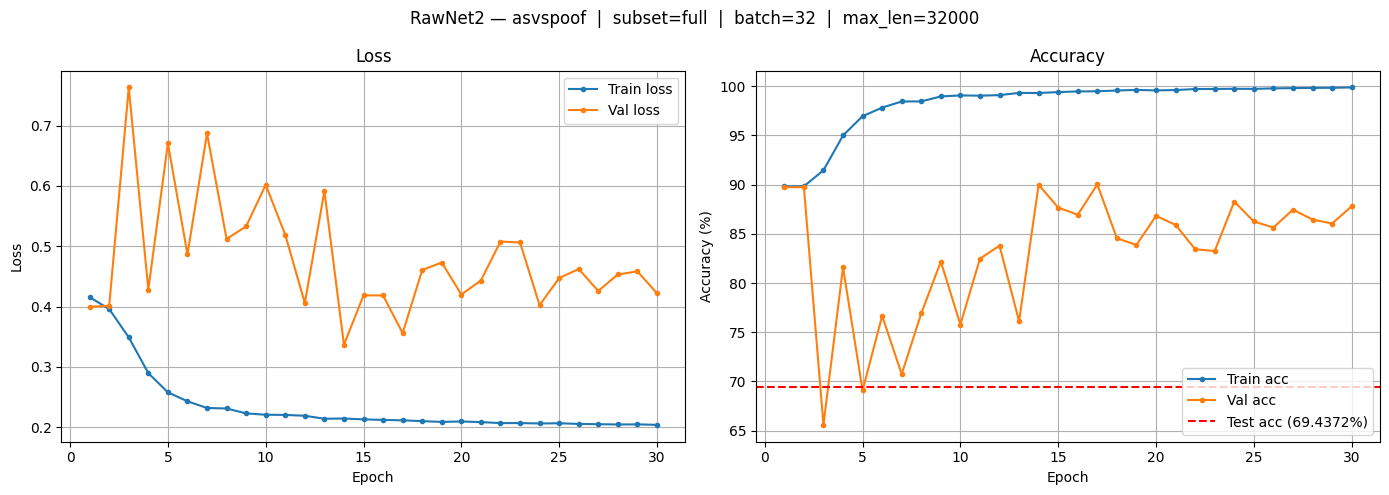


Final Results:
  Train : 90.7644%
  Val   : 88.2708%
  Test  : 69.4372%
Plot saved to: /content/drive/MyDrive/MSAI/AI-600/project/results/best_model_asvspoof_metrics_plot.png


In [ ]:

import json, matplotlib.pyplot as plt

METRICS_SAVE = MODEL_SAVE.replace(".pt", "_metrics.json")
with open(METRICS_SAVE) as f:
    history = json.load(f)

epochs = [e["epoch"] for e in history["epochs"]]
tr_losses= [e["train_loss"] for e in history["epochs"]]
va_losses= [e["val_loss"] for e in history["epochs"]]
tr_accs = [e["train_acc"]  for e in history["epochs"]]
va_accs = [e["val_acc"] for e in history["epochs"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"RawNet2 — {history['dataset']}  |  "
             f"subset={history['subset_per_class'] or 'full'}  |  "
             f"batch={history['batch_size']}  |  max_len={history['max_len']}",
             fontsize=12)

# Loss
ax1.plot(epochs, tr_losses, label="Train loss", marker="o", markersize=3)
ax1.plot(epochs, va_losses, label="Val loss",   marker="o", markersize=3)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss"); ax1.legend(); ax1.grid(True)

# Accuracy
ax2.plot(epochs, tr_accs, label="Train acc", marker="o", markersize=3)
ax2.plot(epochs, va_accs, label="Val acc",   marker="o", markersize=3)
ax2.axhline(history["final"].get("test_acc", 0),
            color="red", linestyle="--", label=f"Test acc ({history['final'].get('test_acc', '?')}%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plot_path = METRICS_SAVE.replace(".json", "_plot.png")
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"\nFinal Results:")
print(f"  Train : {history['final'].get('train_acc', '?')}%")
print(f"  Val   : {history['final'].get('val_acc',   '?')}%")
print(f"  Test  : {history['final'].get('test_acc',  '?')}%")
print(f"Plot saved to: {plot_path}")

In [ ]:
from collections import defaultdict

def build_attack_map(data_root):
    proto_dir = os.path.join(data_root, "ASVspoof2019_LA_cm_protocols")
    protocols = [
        "ASVspoof2019.LA.cm.train.trn.txt",
        "ASVspoof2019.LA.cm.dev.trl.txt",
        "ASVspoof2019.LA.cm.eval.trl.txt",
    ]
    attack_map = {}
    for fname in protocols:
        path = os.path.join(proto_dir, fname)
        if not os.path.exists(path):
            continue
        with open(path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                attack_map[parts[1]] = parts[3] 
    return attack_map


def evaluate_per_attack(model, file_list, attack_map, device, split_name="test"):

    model.eval()

    correct_per= defaultdict(int)
    total_per = defaultdict(int)
    spoof_scores_per  = defaultdict(list) 
    bonafide_scores = [] 
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for file_path, true_label in tqdm(file_list, desc=f"Eval [{split_name}]", leave=False):
            w_f, sr = torchaudio.load(file_path)
            if sr != SAMPLE_RATE:
                w_f = torchaudio.functional.resample(w_f, sr, SAMPLE_RATE)
            w_f = w_f.mean(dim=0) if w_f.shape[0] > 1 else w_f.squeeze(0)
            w_f = F.normalize(w_f, p=2, dim=0)
            w_f = (w_f[:MAX_LEN] if w_f.shape[0] >= MAX_LEN
                        else F.pad(w_f, (0, MAX_LEN - w_f.shape[0])))

            inp = w_f.unsqueeze(0).to(device)
            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                out = model(inp)

            prob_spoof = torch.softmax(out, dim=1)[0, 1].item()   # P(spoof)
            pred       = torch.argmax(out, dim=1).item()

            file_id     = os.path.splitext(os.path.basename(file_path))[0]
            attack_type = attack_map.get(file_id, "unknown")
            label_key   = "bonafide" if attack_type == "-" else attack_type

            total_per[label_key]   += 1
            correct_per[label_key] += int(pred == true_label)
            all_scores.append(prob_spoof)
            all_labels.append(true_label)

            if attack_type == "-":
                bonafide_scores.append(prob_spoof)
            else:
                spoof_scores_per[attack_type].append(prob_spoof)

    print(f"\nPer-attack results [{split_name}]")
    print(f"{'Attack':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10} {'EER':>8}")
    print("-" * 52)

    overall_c, overall_t = 0, 0
    bonafide_labels = [0] * len(bonafide_scores)

    for key in sorted(total_per.keys()):
        c, t = correct_per[key], total_per[key]
        overall_c += c; overall_t += t

        if key == "bonafide":
            print(f"  {key:<10} {c:>8} {t:>8} {100*c/t:>9.2f}%{'':>8}-")
        else:
            all_labels = bonafide_labels + [1] * len(spoof_scores_per[key])
            all_labels = bonafide_scores  + spoof_scores_per[key]
            eer = compute_eer(all_labels, all_labels)
            print(f"  {key:<10} {c:>8} {t:>8} {100*c/t:>9.2f}% {eer:>7.2f}%")

    # Overall EER across all samples
    overall_eer = compute_eer(all_labels, all_scores)
    print("-" * 52)
    print(f"  {'OVERALL':<10} {overall_c:>8} {overall_t:>8} "
          f"{100*overall_c/overall_t:>9.2f}% {overall_eer:>7.2f}%")
    return correct_per, total_per

model.load_state_dict(torch.load(MODEL_SAVE, map_location=device))
attack_map = build_attack_map(ASVSPOOF_DATA_ROOT)

evaluate_per_attack(model, test_list, attack_map, device, split_name="test")
evaluate_per_attack(model, val_list,  attack_map, device, split_name="val")


Per-attack results [test]
Attack        Correct    Total   Accuracy      EER
----------------------------------------------------
  A07            4496     4914     91.49%    5.13%
  A08            4005     4914     81.50%    7.11%
  A09            3796     4914     77.25%    8.80%
  A10            2711     4914     55.17%   14.46%
  A11            4117     4914     83.78%    6.80%
  A12            1785     4914     36.32%   18.85%
  A13            4304     4914     87.59%    6.40%
  A14            4461     4914     90.78%    5.68%
  A15            2018     4914     41.07%   18.78%
  A16            4240     4914     86.28%    6.51%
  A17             406     4914      8.26%   31.62%
  A18            1825     4914     37.14%   18.12%
  A19            4249     4914     86.47%    7.87%
  bonafide       7059     7355     95.98%        -
----------------------------------------------------
  OVERALL       49472    71237     69.45%   14.26%



Per-attack results [val]
Attack        Correct    Total   Accuracy      EER
----------------------------------------------------
  A01            3078     3716     82.83%    7.26%
  A02            3548     3716     95.48%    4.44%
  A03            2972     3716     79.98%    9.67%
  A04            3158     3716     84.98%    7.26%
  A05            3318     3716     89.29%    7.65%
  A06            3401     3716     91.52%    6.03%
  bonafide       2441     2548     95.80%        -
----------------------------------------------------
  OVERALL       21916    24844     88.21%    7.26%


(defaultdict(int,
             {'bonafide': 2441,
              'A01': 3078,
              'A02': 3548,
              'A03': 2972,
              'A04': 3158,
              'A05': 3318,
              'A06': 3401}),
 defaultdict(int,
             {'bonafide': 2548,
              'A01': 3716,
              'A02': 3716,
              'A03': 3716,
              'A04': 3716,
              'A05': 3716,
              'A06': 3716}))

In [ ]:
def predict_one(model, audio_path, device, sample_rate=16000, max_len=1000):

  w_f, sr = torchaudio.load(audio_path)
  if sr != sample_rate:
    w_f = torchaudio.functional.resample(w_f, sr, sample_rate)
  if w_f.shape[0] > 1:
    w_f = torch.mean(w_f, dim=0, keepdim=True)
  w_f = w_f.squeeze(0)
  w_f = torch.nn.functional.normalize(w_f, p=2, dim=0)

  if w_f.shape[0] >= max_len:
    w_f = w_f[:max_len]
  else:
    w_f = torch.nn.functional.pad(w_f, (0, max_len - w_f.shape[0]))

  model.eval()
  with torch.no_grad():
    w_f = w_f.unsqueeze(0).to(device)
    output = model(w_f)
    probs = torch.softmax(output, dim=1)
    prob_real, prob_fake = probs[0, 0].item(), probs[0, 1].item()
    predicted_class = 0 if prob_real > prob_fake else 1

  return predicted_class, prob_real, prob_fake

audio_path = "harvard.wav"
predicted_class, prob_real, prob_fake = predict_one(model, audio_path, device)

print(f"prediction: {'real' if predicted_class == 0 else 'fake'}")
print(f"confidence - real: {prob_real:.2%}, fake: {prob_fake:.2%}")